Merge dos datasets

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

df1 = pd.read_csv("./raw/us-financial-indicators/main.csv", parse_dates=["date"])
df2 = pd.read_csv("./raw/how-financial-crisis-are-born/global_crisis_data.csv")

df2_us = df2[df2["iso3"] == "USA"].copy()
df2_us["year"] = df2_us["year"].astype(int)

df1["year"] = df1["date"].dt.year

df1_anual = df1.groupby("year")[[
    "Interest_Rate","Inflation","GDP",
    "Unemployment","Ind_Prod","sp500"
]].mean().reset_index()

cols_df2 = [
    "year","crisis_any","crisis_next_12m",
    "banking_crisis_next_12m","currency_crisis_next_12m",
    "fed_funds_rate","real_interest_rate_10y"
]
cols_df2 = [c for c in cols_df2 if c in df2_us.columns]

df_merged = pd.merge(df1_anual, df2_us[cols_df2], on="year", how="inner")

features = ["Interest_Rate", "Inflation", "GDP", "Unemployment", "Ind_Prod", "sp500"]

df_pca = df_merged[features + ["crisis_any", "crisis_next_12m", "year"]].dropna()

Divisão treino/teste

In [29]:
from sklearn.model_selection import train_test_split

X = df_pca[features]
y = df_pca["crisis_next_12m"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

Função base + coleta de resultados

In [30]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score

resultados = []

def avaliar_modelo(model, X_train, X_test, y_train, y_test, nome_modelo="Modelo"):
    
    print(f"\n===== {nome_modelo} =====")
    
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    print("\n--- TESTE ---")
    print(classification_report(y_test, y_pred_test))
    
    # salvar resultado
    resultados.append({
        "Modelo": nome_modelo,
        "F1": f1_score(y_test, y_pred_test),
        "Accuracy": accuracy_score(y_test, y_pred_test)
    })
    
    # MATRIZ TREINO
    cm_train = confusion_matrix(y_train, y_pred_train)
    ConfusionMatrixDisplay(cm_train).plot()
    plt.title(f"{nome_modelo} - Treino")
    plt.show()
    
    # MATRIZ TESTE
    cm_test = confusion_matrix(y_test, y_pred_test)
    ConfusionMatrixDisplay(cm_test).plot()
    plt.title(f"{nome_modelo} - Teste")
    plt.show()

Árvore de Decisão

Melhores parâmetros:
{'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}

===== Árvore de Decisão =====

--- TESTE ---
              precision    recall  f1-score   support

         0.0       0.92      1.00      0.96        11
         1.0       1.00      0.50      0.67         2

    accuracy                           0.92        13
   macro avg       0.96      0.75      0.81        13
weighted avg       0.93      0.92      0.91        13



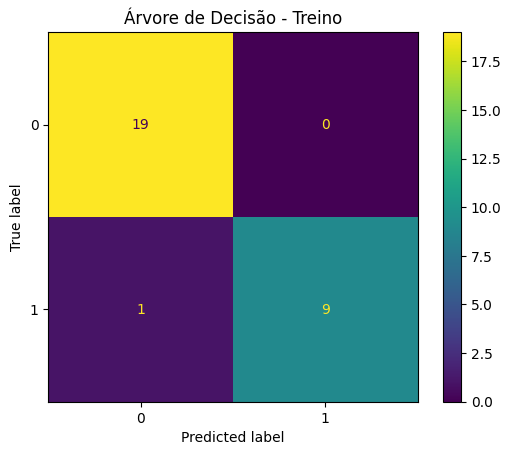

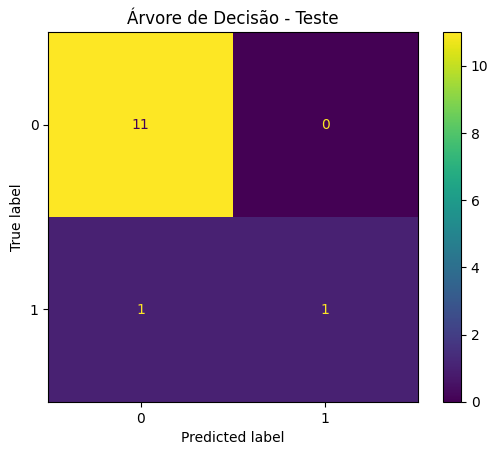

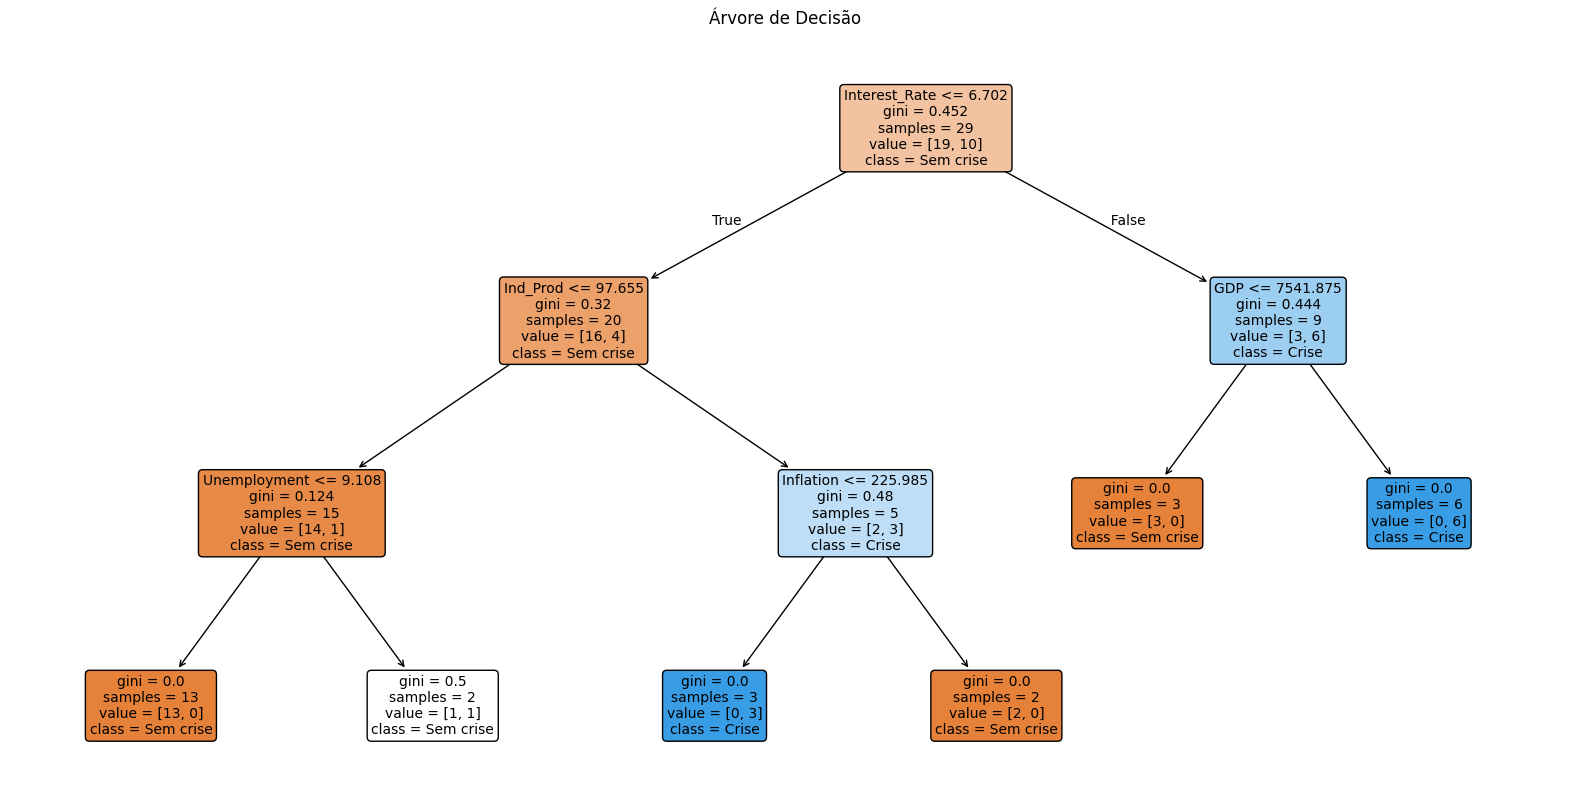

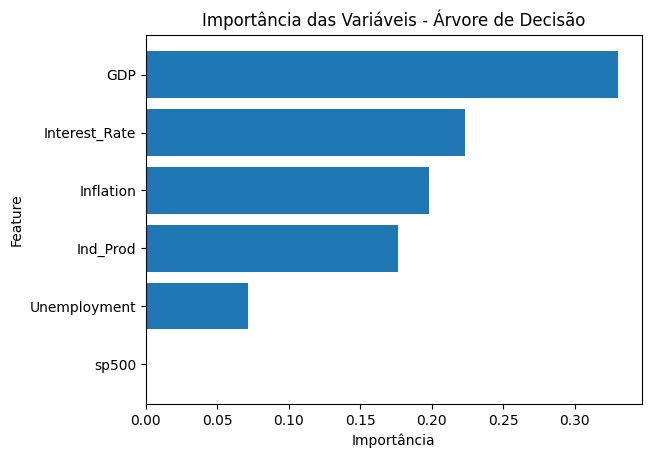

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
import pandas as pd
import matplotlib.pyplot as plt

# ===== GRID DE HIPERPARÂMETROS =====
param_grid = {
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# ===== MODELO BASE =====
tree = DecisionTreeClassifier(random_state=42)

# ===== GRID SEARCH =====
grid = GridSearchCV(
    tree,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

# ===== TREINAR =====
grid.fit(X_train, y_train)

# ===== MELHOR MODELO =====
best_tree = grid.best_estimator_

print("Melhores parâmetros:")
print(grid.best_params_)

# ===== AVALIAÇÃO =====
avaliar_modelo(
    best_tree,
    X_train,
    X_test,
    y_train,
    y_test,
    nome_modelo="Árvore de Decisão"
)

# ===== PLOT DA ÁRVORE =====
plt.figure(figsize=(20,10))

plot_tree(
    best_tree,
    feature_names=features,
    class_names=["Sem crise", "Crise"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Árvore de Decisão")
plt.show()

# ===== IMPORTÂNCIA DAS VARIÁVEIS =====
importances = best_tree.feature_importances_

df_importance = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

plt.figure()
plt.barh(df_importance["feature"], df_importance["importance"])
plt.gca().invert_yaxis()
plt.title("Importância das Variáveis - Árvore de Decisão")
plt.xlabel("Importância")
plt.ylabel("Feature")
plt.show()

KNN

Melhores parâmetros: {'model__n_neighbors': 3, 'model__weights': 'distance'}

===== KNN =====

--- TESTE ---
              precision    recall  f1-score   support

         0.0       1.00      0.82      0.90        11
         1.0       0.50      1.00      0.67         2

    accuracy                           0.85        13
   macro avg       0.75      0.91      0.78        13
weighted avg       0.92      0.85      0.86        13



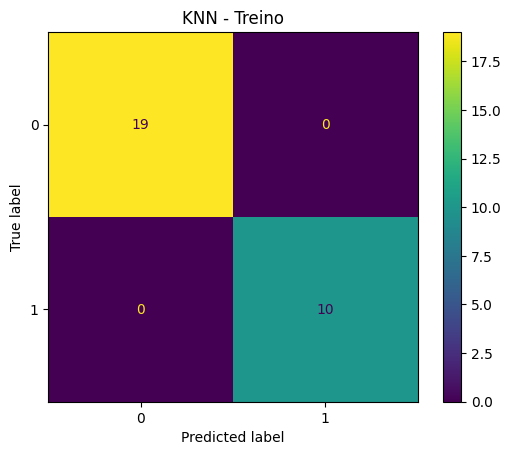

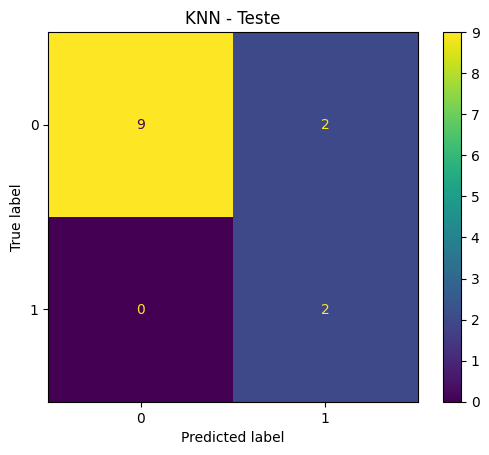

In [32]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

param_grid = {
    "model__n_neighbors": [3,5,7,9,11],
    "model__weights": ["uniform","distance"]
}

grid = GridSearchCV(knn_pipeline, param_grid, cv=5, scoring="f1", n_jobs=-1)
grid.fit(X_train, y_train)

best_knn = grid.best_estimator_

print("Melhores parâmetros:", grid.best_params_)

avaliar_modelo(best_knn, X_train, X_test, y_train, y_test, "KNN")

Voting Classifier


===== Voting Ensemble =====

--- TESTE ---
              precision    recall  f1-score   support

         0.0       0.91      0.91      0.91        11
         1.0       0.50      0.50      0.50         2

    accuracy                           0.85        13
   macro avg       0.70      0.70      0.70        13
weighted avg       0.85      0.85      0.85        13



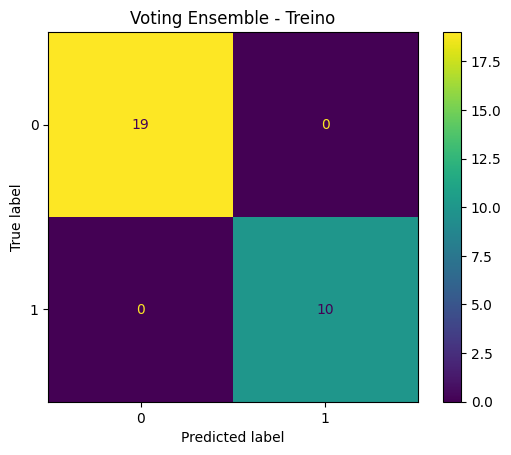

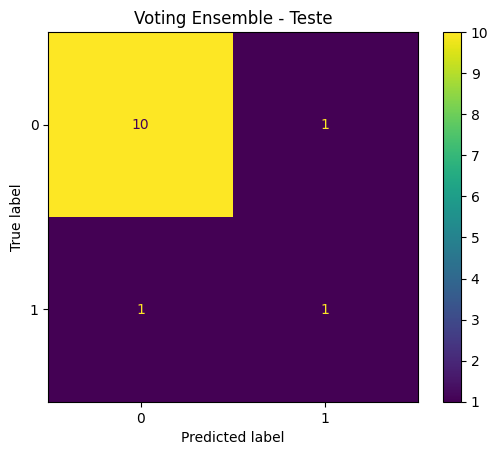

In [33]:
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression

knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=7))
])

tree = DecisionTreeClassifier(max_depth=5, random_state=42)

rf = RandomForestClassifier(n_estimators=200, random_state=42)

logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

voting = VotingClassifier(
    estimators=[
        ("knn", knn),
        ("tree", tree),
        ("rf", rf),
        ("logreg", logreg)
    ],
    voting="soft"
)

voting.fit(X_train, y_train)

avaliar_modelo(voting, X_train, X_test, y_train, y_test, "Voting Ensemble")

Random Forest

Melhores parâmetros: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

===== Random Forest =====

--- TESTE ---
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        11
         1.0       1.00      1.00      1.00         2

    accuracy                           1.00        13
   macro avg       1.00      1.00      1.00        13
weighted avg       1.00      1.00      1.00        13



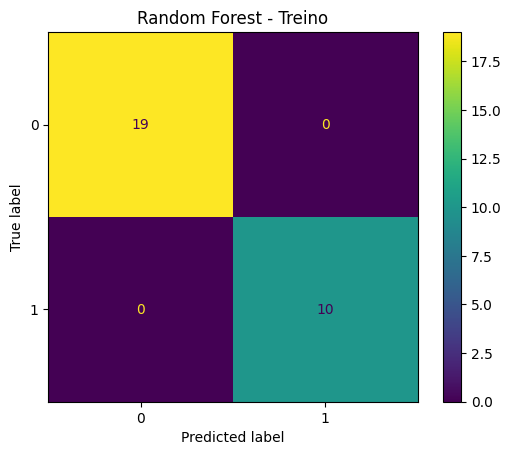

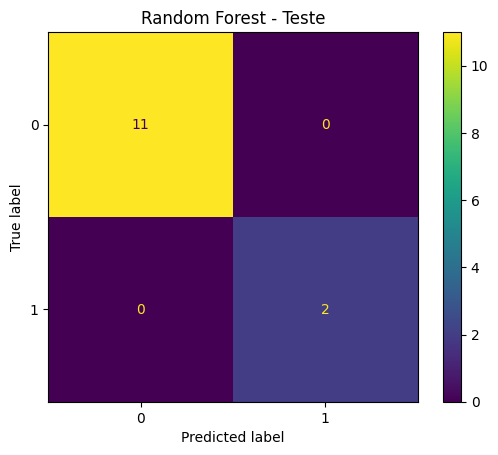

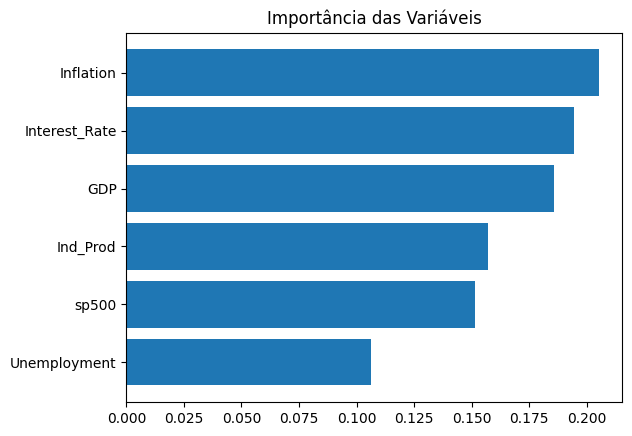

In [34]:
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "class_weight": [None, "balanced"]
}

rf = RandomForestClassifier(random_state=42)

grid = GridSearchCV(rf, param_grid, cv=5, scoring="f1", n_jobs=-1)
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

print("Melhores parâmetros:", grid.best_params_)

avaliar_modelo(best_rf, X_train, X_test, y_train, y_test, "Random Forest")

# importância
importances = best_rf.feature_importances_

df_importance = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

plt.figure()
plt.barh(df_importance["feature"], df_importance["importance"])
plt.gca().invert_yaxis()
plt.title("Importância das Variáveis")
plt.show()

Comparação final dos modelos

              Modelo        F1  Accuracy
3      Random Forest  1.000000  1.000000
0  Árvore de Decisão  0.666667  0.923077
1                KNN  0.666667  0.846154
2    Voting Ensemble  0.500000  0.846154


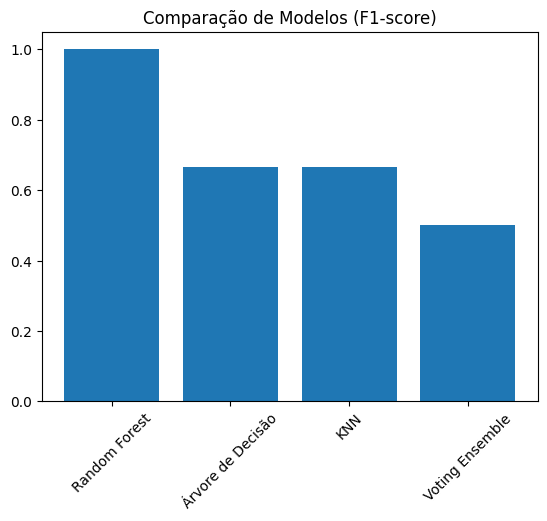

In [35]:
df_resultados = pd.DataFrame(resultados).sort_values(by="F1", ascending=False)

print(df_resultados)

plt.figure()
plt.bar(df_resultados["Modelo"], df_resultados["F1"])
plt.title("Comparação de Modelos (F1-score)")
plt.xticks(rotation=45)
plt.show()